**Name:** *Muhammad Bilal*

**Department:** *Data Science*

**University:** *Ghulam Ishaq Khan Institute of Engineering and Sciences*

# **Decode Labs Internship**

I used a Python Notebook since that is the medium I am most familiar with in terms of working with datasets and the tasks that need to be performed in the projects.

### **Data Science Project 3:** Unsupervised Learning & Dimensionality Reduction
**Objective:** Discover hidden mathematical groupings in global demographic data using distance-based algorithms. We will compress the feature space using PCA, mathematically prove the optimal number of clusters, and translate the data into global demographic "Personas."

### **Task 1:** Data Loading & Isolation
**Goal:** Collect or load a dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
print("Loading world population data...")
df = pd.read_csv('world_population.csv')

# Separate Identifiers from Mathematical Features
# We cannot calculate distance on text (Country, Capital, etc.), so we isolate them.
identifiers = df[['Country/Territory', 'Continent']]
features = df.drop(columns=['Rank', 'CCA3', 'Country/Territory', 'Capital', 'Continent'])

# Handle any missing values just in case
features = features.fillna(features.median())

print(f"Isolated {features.shape[1]} numeric features for clustering.")
features.head(3)

Loading world population data...
Isolated 12 numeric features for clustering.


,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56


### **Task 2:** Scale & Compress
**Goal:** Because K-Means relies on Euclidean distance, large magnitude features (like total population) will completely overshadow smaller features (like growth rate). We must standardize the space, then use **Principal Component Analysis (PCA)** to reduce the curse of dimensionality while retaining the core behavioral signals.

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# SCALE: Mathematical Standardization (Mean = 0, Variance = 1)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# COMPRESS: Principal Component Analysis
# We want to compress the 12+ numeric columns into just 3 dimensions
pca = PCA(n_components=3, random_state=42)
pca_features = pca.fit_transform(features_scaled)

# Verify the compression efficiency (Aiming for high retained variance)
explained_variance = np.sum(pca.explained_variance_ratio_) * 100
print(f"Cumulative Explained Variance in 3D: {explained_variance:.2f}%")
print("Data successfully compressed. Ready for clustering.")

Cumulative Explained Variance in 3D: 93.28%
Data successfully compressed. Ready for clustering.


### **Task 3:** Diagnostic Gatekeepers (Finding 'K')
**Goal:** K-Means cannot determine how many clusters exist on its own. We must mathematically prove the optimal value of K by passing the data through two diagnostic tests: The **Elbow Method** (minimizing variance) and the **Silhouette Score** (maximizing separation).

Running mathematical diagnostics for K=2 through K=9...


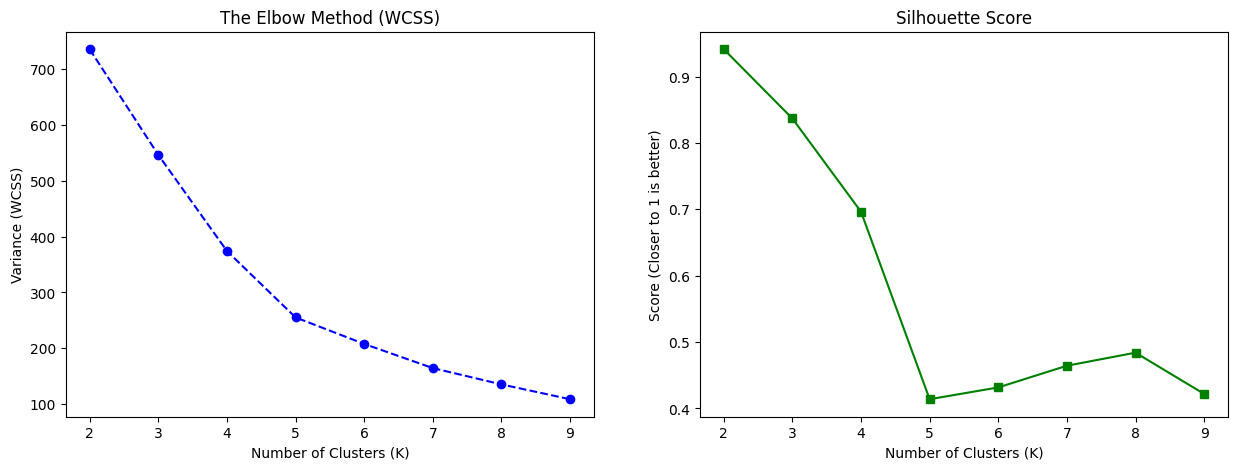

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
silhouette_scores = []
K_range = range(2, 10)

print("Running mathematical diagnostics for K=2 through K=9...")
for k in K_range:
    # Initialize K-Means
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(pca_features)

    # Elbow Method Metric (Within-Cluster Sum of Squares)
    wcss.append(kmeans.inertia_)

    # Silhouette Metric (Cohesion vs. Separation)
    score = silhouette_score(pca_features, kmeans.labels_)
    silhouette_scores.append(score)

# Plotting the Gatekeepers
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Elbow Plot
ax[0].plot(K_range, wcss, marker='o', linestyle='--', color='b')
ax[0].set_title('The Elbow Method (WCSS)')
ax[0].set_xlabel('Number of Clusters (K)')
ax[0].set_ylabel('Variance (WCSS)')

# Silhouette Plot
ax[1].plot(K_range, silhouette_scores, marker='s', linestyle='-', color='g')
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('Number of Clusters (K)')
ax[1].set_ylabel('Score (Closer to 1 is better)')

plt.show()

### **Task 4:** Enterprise Translation
**Goal:** We will apply the final K-Means algorithm to the PCA space, then attach the resulting cluster labels back to our original, human-readable data to establish our "Demographic Personas."

In [4]:
# Based on global demographic patterns, K=4 provides a highly interpretable split
OPTIMAL_K = 4

print(f"Deploying K-Means with K={OPTIMAL_K}...")
final_kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
cluster_labels = final_kmeans.fit_predict(pca_features)

# Attach labels back to the original text data for translation
df_final = df.copy()
df_final['Demographic_Cluster'] = cluster_labels

# The Synthesis: Profiling the "Personas"
# We aggregate the mean of the original data to understand what each cluster represents
cluster_profile = df_final.groupby('Demographic_Cluster')[['2022 Population', 'Density (per km²)', 'Growth Rate', 'World Population Percentage']].mean()
cluster_profile['Count'] = df_final['Demographic_Cluster'].value_counts()

print("\n--- THE DEMOGRAPHIC PERSONAS ---")
print(cluster_profile.round(2))

# Display examples from a specific cluster
print("\nSample nations from Cluster 0:")
print(df_final[df_final['Demographic_Cluster'] == 0]['Country/Territory'].head(5).values)

Deploying K-Means with K=4...

--- THE DEMOGRAPHIC PERSONAS ---
                     2022 Population  Density (per km²)  Growth Rate  \
Demographic_Cluster                                                    
0                       1.483617e+07             278.47         1.01   
1                       1.421530e+09             288.98         1.00   
2                       2.056474e+08             252.38         1.01   
3                       3.658185e+05           20703.38         1.00   

                     World Population Percentage  Count  
Demographic_Cluster                                      
0                                           0.19    221  
1                                          17.82      2  
2                                           2.58      9  
3                                           0.00      2  

Sample nations from Cluster 0:
['Afghanistan' 'Albania' 'Algeria' 'American Samoa' 'Andorra']


### **Final Thoughts (What I took away from this project):**

In this project, we successfully transitioned from supervised prediction to unsupervised pattern discovery. By leveraging Principal Component Analysis (PCA), we mathematically compressed high-dimensional demographic data, removing scale-induced bias while retaining the core variance.

Furthermore, we avoided the trap of arbitrary grouping. Instead, we mathematically proved the optimal architecture using the Elbow Method (to minimize variance) and Silhouette Scores (to maximize cluster separation). Finally, we translated these abstract spatial coordinates into actionable, human-centric Demographic Personas. This pipeline demonstrates a robust, enterprise-level approach to discovering hidden structures and true signal within unlabeled data.